In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

dataFrame = pd.read_excel("bisiklet_fiyatlari.xlsx")

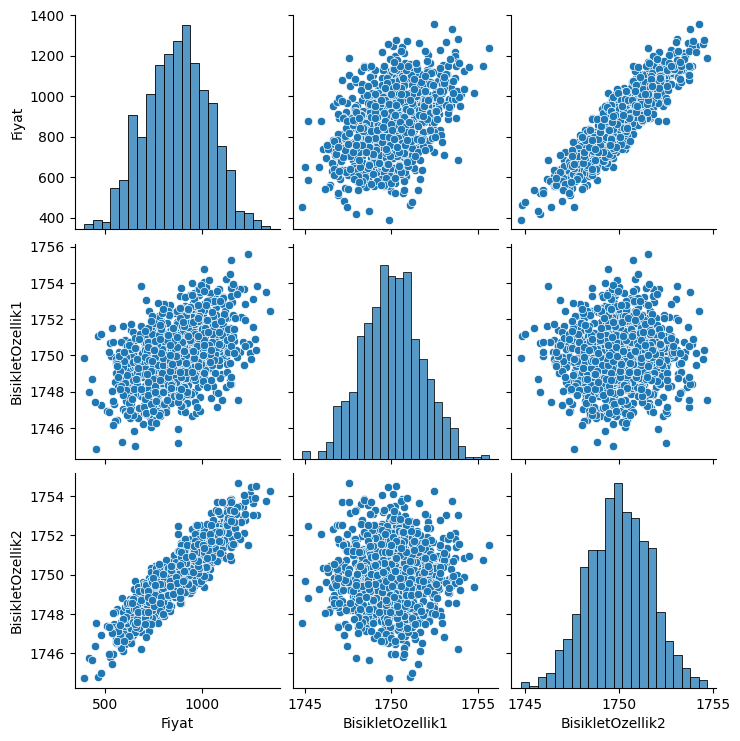

In [6]:
sbn.pairplot(dataFrame)

veriyi test/train olarak ikiye ayırmak 

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
y = dataFrame["Fiyat"].values

x = dataFrame[["BisikletOzellik1", "BisikletOzellik2"]].values

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.33, random_state=15)

In [9]:
x_test.shape

(330, 2)

In [10]:
x_train.shape

(670, 2)

## scaling

In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
scaler = MinMaxScaler()

In [13]:
scaler.fit(x_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [14]:
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

In [15]:
x_train

array([[0.3177906 , 0.64341466],
       [0.61991638, 0.89583174],
       [0.53950097, 0.0980286 ],
       ...,
       [0.2352117 , 0.52644765],
       [0.7576794 , 0.19157421],
       [0.4292982 , 0.16530301]], shape=(670, 2))

In [25]:
import tensorFlow as tlf

Epoch 1/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 795882.5000
Epoch 2/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 795796.3125 
Epoch 3/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 795713.0000 
Epoch 4/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 795623.5625
Epoch 5/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 795526.7500 
Epoch 6/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 795421.8125 
Epoch 7/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 795307.5625 
Epoch 8/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 795183.0625 
Epoch 9/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 795047.0000 
Epoch 10/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 794900.0625 
Epoch 11/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 794739.9375 
Epoch 12/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 794565.5625 
Epoch 13/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 794377.3125 
Epoch 14/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 79

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [27]:
model = Sequential()

model.add(Dense(4, activation="relu"))
model.add(Dense(4, activation="relu"))
model.add(Dense(4, activation="relu"))

model.add(Dense(1))

model.compile(optimizer="rmsprop", loss="mse")

In [30]:
model.fit(x_train, y_train, epochs=250)

Epoch 1/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 795780.9375
Epoch 2/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 795577.3125 
Epoch 3/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 795373.2500
Epoch 4/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 795154.5000 
Epoch 5/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 794919.1875 
Epoch 6/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 794662.6875
Epoch 7/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 794383.2500  
Epoch 8/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 794079.4375 
Epoch 9/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 793751.6875 
Epoch 10/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 793398.5625
Epoch 11/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 793013.6250 
Epoch 12/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 792583.9375 
Epoch 13/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 792105.8125 
Epoch 14/250
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 791

In [33]:
loss = model.history.history["loss"]

<Axes: >

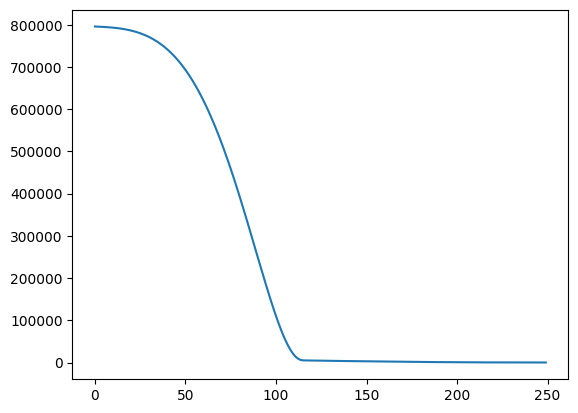

In [34]:
sbn.lineplot(x=range(len(loss)), y=loss)

In [37]:
trainLoss = model.evaluate(x_train, y_train, verbose=0)

In [38]:
testLoss = model.evaluate(x_test, y_test, verbose=0)

In [39]:
trainLoss

78.46202087402344

In [40]:
testLoss

77.91729736328125

In [41]:
testTahminleri = model.predict(x_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [42]:
testTahminleri

array([[1075.9886 ],
       [ 626.8683 ],
       [ 876.2611 ],
       [ 895.7695 ],
       [ 901.2351 ],
       [ 459.0362 ],
       [ 931.2562 ],
       [ 991.1493 ],
       [ 939.7573 ],
       [1015.7971 ],
       [ 752.44867],
       [ 916.83203],
       [ 948.2246 ],
       [1052.9125 ],
       [1117.9817 ],
       [ 684.64844],
       [1125.8322 ],
       [ 655.5557 ],
       [1153.3593 ],
       [ 886.64685],
       [ 893.1781 ],
       [ 718.0005 ],
       [ 460.7593 ],
       [ 616.9919 ],
       [ 835.3071 ],
       [1088.681  ],
       [ 716.5094 ],
       [ 759.1996 ],
       [ 874.8019 ],
       [ 772.6912 ],
       [ 457.29434],
       [ 783.9775 ],
       [ 730.641  ],
       [ 650.60767],
       [ 887.4513 ],
       [ 844.91016],
       [1034.1576 ],
       [1022.6311 ],
       [ 845.38574],
       [ 863.38354],
       [ 758.8108 ],
       [1172.5233 ],
       [1095.6199 ],
       [1085.7252 ],
       [ 872.3257 ],
       [ 600.1924 ],
       [1144.8204 ],
       [ 973.

In [52]:
tahminDf = pd.DataFrame(y_test, columns=["Gerçek Y"])

In [53]:
tahminDf

,Gerçek Y
0,1081.652164
1,622.675990
2,889.356810
3,902.826733
4,897.662404
...,...
325,1028.438035
326,789.934950
327,758.490486
328,1172.871659


In [45]:
testTahminleri = pd.Series(testTahminleri.reshape(330,))

In [55]:
tahminDf = pd.concat([tahminDf, testTahminleri], axis=1)

In [58]:
tahminDf.columns = ["Gerçek Y", "Tahmin Y"]

In [59]:
tahminDf

,Gerçek Y,Tahmin Y
0,1081.652164,1075.988647
1,622.675990,626.868286
2,889.356810,876.261108
3,902.826733,895.769470
4,897.662404,901.235107
...,...,...
325,1028.438035,1012.170166
326,789.934950,793.178833
327,758.490486,767.151733
328,1172.871659,1164.360474


<Axes: xlabel='Gerçek Y', ylabel='Tahmin Y'>

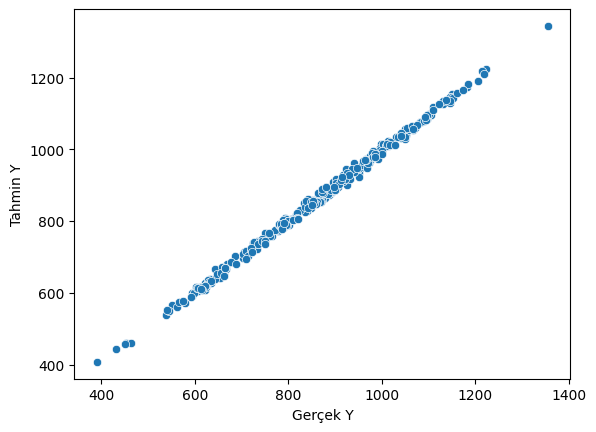

In [60]:
sbn.scatterplot(x = "Gerçek Y", y="Tahmin Y", data=tahminDf)

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [62]:
mean_absolute_error(tahminDf["Gerçek Y"], tahminDf["Tahmin Y"])

7.051869788177083

In [63]:
mean_squared_error(tahminDf["Gerçek Y"], tahminDf["Tahmin Y"])

77.91729701180125

In [64]:
dataFrame.describe()

,Fiyat,BisikletOzellik1,BisikletOzellik2
count,1000.000000,1000.000000,1000.000000
mean,872.677801,1750.024800,1749.964733
std,164.124504,1.704531,1.659578
min,390.856887,1744.852108,1744.742389
25%,757.795031,1748.831119,1748.803186
50%,879.168705,1750.017350,1750.003926
75%,988.612778,1751.115765,1751.129414
max,1355.213745,1755.613884,1754.666038


In [71]:
yeniBisikletOzellikleri = [[1751, 1750]]

In [72]:
yeniBisikletOzellikleri = scaler.transform(yeniBisikletOzellikleri)

In [73]:
model.predict(yeniBisikletOzellikleri)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


array([[914.0911]], dtype=float32)

In [83]:
from tensorflow.keras.models import load_model

In [84]:
model.save("bisiklet_modeli.h5")

In [85]:
sonradanCagirilanModel = load_model("bisiklet_modeli.h5", compile=False)

In [86]:
sonradanCagirilanModel.predict(yeniBisikletOzellikleri)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step


array([[914.0911]], dtype=float32)